# Biomarker S4 — Baseline multi-level classifier (KL grade) trên bảng biomarker

Input: `biomarker_table.csv` từ **S3**. Đây là bước cuối: train 1 classifier multi-class
(KL 0–4) trên các biomarker thể tích/thickness/denuded/extrusion đã trích, và dùng SHAP để xem
biomarker/compartment nào đóng góp nhiều nhất — đây mới là cách dùng SHAP đúng chỗ (feature
bảng, không phải pixel ảnh như ở `OAI_SHAP_pipeline_v6` cũ).

**Quan trọng — tách theo subject, không theo case:** một subject có thể xuất hiện ở nhiều visit
hoặc cả 2 side → nếu chia train/test theo case ngẫu nhiên sẽ bị **rò rỉ dữ liệu** (cùng subject
vừa ở train vừa ở test). Notebook này luôn `GroupShuffleSplit` theo `subject`.


In [1]:
!pip install -q xgboost shap scikit-learn pandas matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0) Load bảng biomarker

In [3]:
from pathlib import Path
import pandas as pd, numpy as np

BIOM_DIR = Path("/content/drive/MyDrive/knee_biomarkers")
df = pd.read_csv(BIOM_DIR / "biomarker_table.csv")
print("so ca:", len(df), "| so subject rieng biet:", df["subject"].nunique())
print(df["KL"].value_counts().sort_index())

FEATURE_COLS = [c for c in df.columns if c.startswith(("vol_", "thickness_", "denuded_", "extrusion_"))]
print("so bien so dung lam feature:", len(FEATURE_COLS))
FEATURE_COLS


so ca: 559 | so subject rieng biet: 554
KL
0    103
1     60
2    137
3    183
4     76
Name: count, dtype: int64
so bien so dung lam feature: 15


['vol_femoral_bone_mm3',
 'vol_femoral_cart_mm3',
 'vol_tibial_bone_mm3',
 'vol_med_tib_cart_mm3',
 'vol_lat_tib_cart_mm3',
 'vol_med_meniscus_mm3',
 'vol_lat_meniscus_mm3',
 'vol_patellar_cart_mm3',
 'thickness_femoral_mm',
 'denuded_ratio_femoral',
 'thickness_med_tib_mm',
 'thickness_lat_tib_mm',
 'denuded_ratio_tibial',
 'extrusion_med_meniscus',
 'extrusion_lat_meniscus']

## 1) Tách train/test theo subject (tránh rò rỉ)

In [4]:
from sklearn.model_selection import GroupShuffleSplit

X = df[FEATURE_COLS].copy()
y = df["KL"].astype(int).copy()
groups = df["subject"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("train:", len(X_train), "| test:", len(X_test))
print("chong lan subject train/test (phai = 0):",
      len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))


train: 444 | test: 115
chong lan subject train/test (phai = 0): 0


## 2) Train baseline XGBoost multi-class

In [5]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

# XGBoost bat buoc nhan class la so nguyen lien tuc tu 0 (vd 0,1,2,3...).
# Cohort thuc te co the KHONG co du ca KL=0 (chi co 1..4) -> phai encode truoc khi fit,
# roi decode lai ve nhan KL that (1..4) khi bao cao ket qua cho de doc.
le = LabelEncoder()
le.fit(y)   # fit tren toan bo y (khong chi y_train) de encoding on dinh, khong phu thuoc vao split
print("cac muc KL thuc te trong du lieu:", list(le.classes_))

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=len(le.classes_),
    eval_metric="mlogloss", random_state=42,
)
clf.fit(X_train, y_train_enc)

pred_enc = clf.predict(X_test)
pred = le.inverse_transform(pred_enc)          # doi ve nhan KL that (vd 1..4) de doc
y_test_true = le.inverse_transform(y_test_enc) # = y_test, chi de dong bo kieu du lieu

print(classification_report(y_test_true, pred, zero_division=0))
print("Quadratic-weighted kappa (chuan cho KL grade, phat sai lech xa nang hon):",
      round(cohen_kappa_score(y_test_true, pred, weights="quadratic"), 3))
print("\nConfusion matrix (hang/cot theo thu tu KL):\n", confusion_matrix(y_test_true, pred, labels=le.classes_))
print("thu tu nhan trong confusion matrix:", list(le.classes_))


cac muc KL thuc te trong du lieu: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
              precision    recall  f1-score   support

           0       0.44      0.48      0.46        23
           1       0.30      0.27      0.29        11
           2       0.50      0.52      0.51        27
           3       0.62      0.76      0.68        37
           4       0.43      0.18      0.25        17

    accuracy                           0.51       115
   macro avg       0.46      0.44      0.44       115
weighted avg       0.50      0.51      0.50       115

Quadratic-weighted kappa (chuan cho KL grade, phat sai lech xa nang hon): 0.634

Confusion matrix (hang/cot theo thu tu KL):
 [[11  5  7  0  0]
 [ 3  3  4  1  0]
 [ 7  2 14  3  1]
 [ 3  0  3 28  3]
 [ 1  0  0 13  3]]
thu tu nhan trong confusion matrix: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3) SHAP — biomarker/compartment nào đóng góp nhiều nhất cho từng mức KL

Đây là use-case SHAP "chuẩn": feature bảng (không phải pixel), diễn giải trực tiếp
theo tên biomarker/compartment.

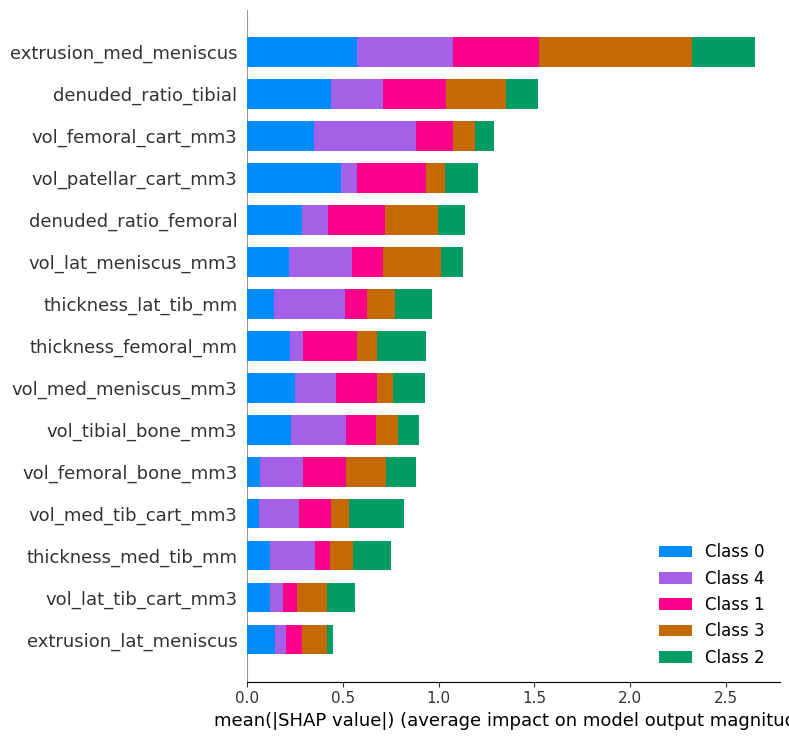

da luu: /content/shap_summary_bar.png


In [6]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)   # list theo class hoac array (n,f,c) tuy phien ban shap

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("/content/shap_summary_bar.png", dpi=150)
plt.show()
print("da luu: /content/shap_summary_bar.png")


## 4) Lưu model + bảng kết quả về Drive

In [7]:
import joblib, shutil

MODEL_DIR = BIOM_DIR / "model_kl_classifier"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(clf, MODEL_DIR / "xgb_kl_classifier.joblib")
pd.DataFrame({"case_id": df.iloc[test_idx]["case_id"], "KL_true": y_test, "KL_pred": pred}) \
    .to_csv(MODEL_DIR / "test_predictions.csv", index=False)
shutil.copy("/content/shap_summary_bar.png", MODEL_DIR / "shap_summary_bar.png")
print("da luu model + ket qua vao:", MODEL_DIR)


da luu model + ket qua vao: /content/drive/MyDrive/knee_biomarkers/model_kl_classifier


## 5) [MỚI] Sensitivity analysis — kết quả có đổi khi chỉ dùng case tin cậy cao không?

So sánh hiệu năng khi train/test trên **toàn bộ cohort** (gồm cả `ai_full_8class` và
`d020_ready_unclear_provenance` — 2 loại chưa rõ mức tin cậy) vs khi **chỉ giữ case có ít nhất
1 phần GT thật** (`gt_real_imorphics` + `partial_gt_oaizib_ai_meniscus_patella`).

Nếu 2 kết quả (accuracy / quadratic-weighted kappa) lệch nhiều (vd kappa lệch > 0.1), nghĩa là
nhãn AI/pseudo đang ảnh hưởng đáng kể tới kết luận — nên kiểm tra thêm `d20_dice_eval.csv`
(từ S2) và QC bằng mắt ở S6 trước khi báo cáo kết quả trên toàn cohort.

In [8]:
from sklearn.metrics import accuracy_score

HIGH_CONF = {"gt_real_imorphics", "partial_gt_oaizib_ai_meniscus_patella"}
assert "source_dataset" in df.columns, "Thieu cot source_dataset -> chay lai ban S1/S2/S3 da patch."

def eval_subset(mask, label):
    sub = df[mask].copy()
    if sub["subject"].nunique() < 10 or sub["KL"].nunique() < 2:
        print(f"[{label}] qua it du lieu/nhan ({len(sub)} ca) -> bo qua")
        return None
    Xs, ys, gs = sub[FEATURE_COLS], sub["KL"].astype(int), sub["subject"].astype(str)
    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_i, te_i = next(gss_s.split(Xs, ys, gs))
    y_enc = le.transform(ys)
    clf_s = XGBClassifier(**clf.get_params())
    clf_s.fit(Xs.iloc[tr_i], y_enc[tr_i])
    pred_s = clf_s.predict(Xs.iloc[te_i])
    acc = accuracy_score(y_enc[te_i], pred_s)
    kappa = cohen_kappa_score(y_enc[te_i], pred_s, weights="quadratic")
    print(f"[{label}] n={len(sub)} | test_n={len(te_i)} | acc={acc:.3f} | qw_kappa={kappa:.3f}")
    return dict(label=label, n=len(sub), accuracy=acc, qw_kappa=kappa)

print("=== So sanh: toan bo cohort vs chi case tin cay cao ===")
res_full = eval_subset(pd.Series(True, index=df.index), "toan_bo_cohort")
res_high = eval_subset(df["source_dataset"].isin(HIGH_CONF), "chi_tin_cay_cao")

if res_full and res_high:
    diff_kappa = abs(res_full["qw_kappa"] - res_high["qw_kappa"])
    print(f"\nchenh lech qw_kappa: {diff_kappa:.3f}")
    if diff_kappa > 0.1:
        print("CANH BAO: chenh lech kappa > 0.1 -> nhan AI/pseudo co the dang anh huong ket qua.")
    else:
        print("Chenh lech nho -> ket qua kha on dinh du co dung them case AI-bu nhan.")


=== So sanh: toan bo cohort vs chi case tin cay cao ===
[toan_bo_cohort] n=559 | test_n=115 | acc=0.513 | qw_kappa=0.634
[chi_tin_cay_cao] n=538 | test_n=107 | acc=0.439 | qw_kappa=0.505

chenh lech qw_kappa: 0.130
CANH BAO: chenh lech kappa > 0.1 -> nhan AI/pseudo co the dang anh huong ket qua.


## Ghi chú
- Đây là **baseline** — mục tiêu là có con số tham chiếu nhanh, không phải model cuối cùng.
  Muốn cải thiện: thêm biomarker BML/effusion (cần segmentation riêng), thử ordinal regression
  thay vì multi-class thuần (KL có thứ tự 0<1<2<3<4), hoặc cross-validation theo subject
  thay vì 1 lần split.
- `cohen_kappa_score(weights="quadratic")` là metric chuẩn để báo cáo cho bài toán KL grading
  trong y văn (phạt nặng hơn khi dự đoán lệch xa, vd 0 dự đoán thành 4).
